## 8.2 学习率衰减策略 - 指定间隔学习率衰减

#### 1. 为什么需要指定间隔学习率衰减
在上一节我们学习了 等间隔学习率衰减（Step Decay）：
* 每隔固定 epoch
* 学习率下降一次

例如：
* 每 10 个 epoch 降一次

但是在实际训练中，我们经常希望：

`在某些特定 epoch 才下降学习率`

例如：
```
第 30 epoch
第 60 epoch
第 90 epoch
```
因为模型训练往往不是完全均匀的：
* 前期下降很快
* 中期下降变慢
* 后期需要精细优化

因此我们可能希望：

在关键阶段手动降低学习率

这就是 指定间隔学习率衰减（Multi-Step Learning Rate Decay）。

#### 2. 什么是指定间隔学习率衰减
指定间隔学习率衰减的核心思想是：

`在指定的若干个 epoch，将学习率按比例降低。`

例如：

初始学习率：

`η₀ = 0.01`

指定衰减 epoch：

`[30, 60, 90]`

衰减比例：

`γ = 0.1`

则学习率变化为：
```
Epoch	学习率
1 ~ 29	0.01
30 ~ 59	0.001
60 ~ 89	0.0001
90 ~ …	0.00001
```
可以看到：

学习率在指定的 epoch 发生下降


#### 3. 指定间隔学习率衰减的数学公式
指定间隔学习率衰减可以表示为：

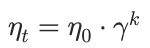

其中：

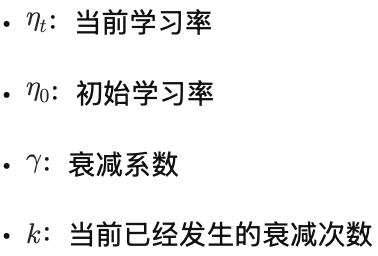

而：

`k = 已经过的 milestone 数量`

例如：

milestones：

`[30, 60, 90]`

已经经过 milestone：

`30`

已经经过 milestone个数：

`1`

所以：

`k = 1`

学习率：

`η = η_0 × γ`

#### 4. 示例计算
假设：
```
η₀ = 0.01
γ = 0.1
milestones = [30, 60, 90]
```

**Epoch < 30**
```
k = 0
η = 0.01
```

**30 ≤ Epoch < 60**
```
k = 1
η = 0.01 × 0.1 = 0.001
```

**60 ≤ Epoch < 90**
```
k = 2
η = 0.01 × 0.1^2 = 0.0001
```

**Epoch ≥ 90**
```
k = 3
η = 0.01 × 0.1^3 = 0.00001
```

学习率变化图示
```
0.01     ───────────────
                         │
0.001                    ───────────────
                                          │
0.0001                                    ───────────────
                                                         │
0.00001
```
可以看到：

学习率在指定时间点发生跳变

#### 5. 与等间隔衰减的区别
```
方法	               下降方式
等间隔衰减（StepLR）	每隔固定 epoch 下降
指定间隔衰减（MultiStepLR）	在指定 epoch 下降
```

**StepLR**

`step_size = 10`

学习率变化的点：

`10,20,30,40...`

**MultiStepLR**

`milestones = [30, 60, 90]`

学习率变化的点：

`30,60,90`

#### 6. 指定间隔学习率衰减的优点
**1️⃣ 灵活性更高**

我们可以根据训练经验指定：

关键训练阶段

例如：
* loss下降变慢时降低学习率。

**2️⃣ 更符合实际训练过程**

很多深度学习论文都会使用：

`30 / 60 / 90 epoch 衰减`

例如：
```
ResNet
ImageNet 训练
```

**3️⃣ 控制更精细**
相比 StepLR：

可以在任意 epoch 降学习率

#### 8. 缺点
**1️⃣ 需要经验设置**

必须提前设定：

`milestones`

如果设定不好：
* 可能影响训练效果

**2️⃣ 不够自动化**
学习率变化完全依赖人工经验。

#### 9. Pytorch 中的实现
在 PyTorch 中使用：

`torch.optim.lr_scheduler.MultiStepLR`

##### 9.1 创建优化器

In [ ]:
import torch 
model = torch.nn.Linear(10, 5)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.1
)

##### 9.2 创建学习率调度器

In [ ]:
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer = optimizer,
    milestones = [5, 10, 15],
    gamma = 0.1
)

参数说明：
* milestones
    * 指定下降学习率的 epoch
* gamma
    * 每次衰减比例

##### 9.3 训练循环

In [ ]:
def train(model, dataloader, optimizer, criterion):

    model.train()

    total_loss = 0

    for x, y in dataloader:

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(dataloader)

    return train_loss

In [ ]:
for epoch in range(100):
    train_loss = train(model, dataloader, optimizer, criterion)
    scheduler.step()